### [ 히스토그램과 정규화 ] <hr>

- 데이터 수집 후 데이터 분포 확인은 1번째 작업
- 이미지 픽셀의 분포를 확인하기 위한 용도
    * 이진화 시에 임계값 선정 시에 확인 
- 정규화
    * 기준이 다른 데이터들의 기준을 맞추는 작업
    * 어느 한쪽에 집중되어 있는 픽셀을 고르게 펴주는 작업

In [23]:
## ===================================
## 모듈 로딩
## ===================================
import cv2
import sys
sys.path.append(r'D:\KDT\VS_KDT_14\[7]_CV')
from cv_utils import printPlots, printPlotImage
import numpy as np

In [24]:
## ===================================
## 데이터 준비
## ===================================
IMG_FILE = '../Data/Images/mountain.jpg'

In [25]:
## ===================================
## 데이터 로딩 및 기본 정보 출력
## ===================================
grayNP  = cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
colorNP = cv2.imread(IMG_FILE)

print(f'[grayNP]  => 형태 : {grayNP.shape},  차원 : {grayNP.ndim}D')
print(f'[colorNP] => 형태 : {colorNP.shape}, 차원 : {colorNP.ndim}D')

[grayNP]  => 형태 : (450, 600),  차원 : 2D
[colorNP] => 형태 : (450, 600, 3), 차원 : 3D


[ 히스토그램 ]<hr>

[garyHist]  => 타입 : <class 'numpy.ndarray'>, 형태 : (256, 1),  차원 : 2D


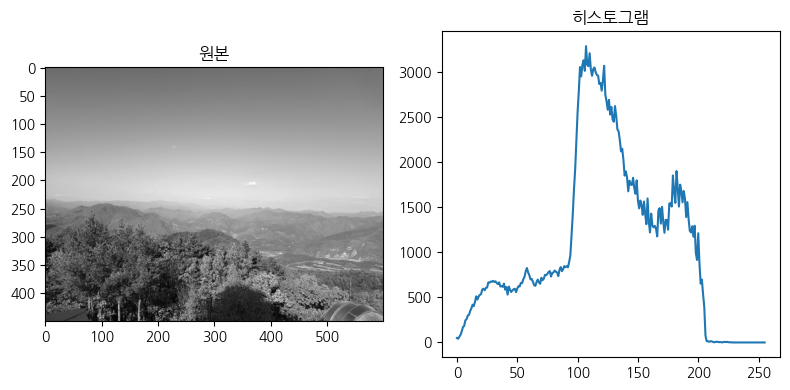

In [26]:
## ===================================
## 이미지 픽셀 데이터 분포 계산 : cv2.calcHist()
## ===================================
## - 이미지객체, 채널 수, 막대수 => List
## - 값의 범위                 => []
grayHist = cv2.calcHist([grayNP], [0], None, [256], [0, 256] )

print(f'[garyHist]  => 타입 : {type(grayHist)}, 형태 : {grayHist.shape},  차원 : {grayHist.ndim}D')

## 시각화 : 원본이미지, 픽셀분포
titles_ = ['원본', '히스토그램']
plots_, images_ = [grayHist] , [grayNP]
cmap_   = ['gray']

printPlotImage(1, 2, titles_, plots_, images_, cmap_)

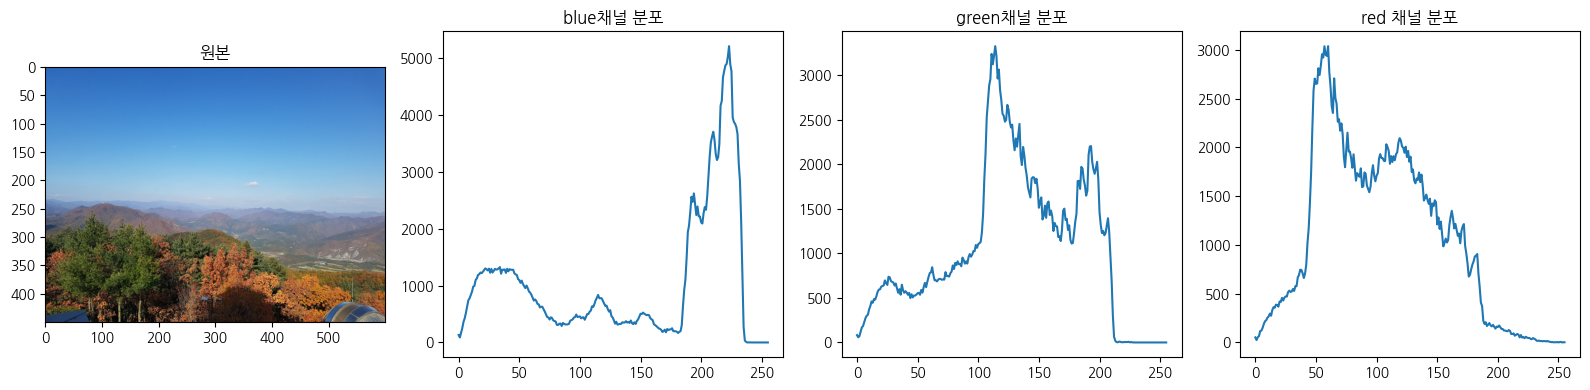

In [27]:
## ====================================================================
## R,G,B 채널별 픽셀 분포
## ====================================================================
blueNP, greenNP, redNP = cv2.split(colorNP)

## => 한꺼번에 3개 계산
rgbHist   = cv2.calcHist([blueNP, greenNP, redNP], [0,1,2], None, 
                         [256, 256, 256], [0, 256, 0, 256, 0, 256])

## => 각각 1개씩 계산
blueHist  = cv2.calcHist([blueNP],  [0], None, [256], [0, 256])
greenHist = cv2.calcHist([greenNP], [0], None, [256], [0, 256])
redHist   = cv2.calcHist([redNP],   [0], None, [256], [0, 256])

## 시각화 : 원본이미지, blue픽셀분포, green픽셀분포, red 픽셀 분포
titles_ = ['원본', 'blue채널 분포', 'green채널 분포', 'red 채널 분포']
plots_, images_ = [blueHist, greenHist, redHist] , [cv2.cvtColor(colorNP, cv2.COLOR_BGR2RGB)]
cmap_   = [None]

printPlotImage(1, 4, titles_, plots_, images_, cmap_)

[ 정규화 ] <hr>

In [28]:
## ==========================================================
## 데이터 준비
## ==========================================================
IMG_FILE = '../Data/Images/abnormal.jpg'

In [29]:
## ===================================
## 데이터 로딩 및 기본 정보 출력
## ===================================
mountNP  = cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)

print(f'[mountNP]  => 형태 : {mountNP.shape},  차원 : {mountNP.ndim}D')

[mountNP]  => 형태 : (360, 480),  차원 : 2D


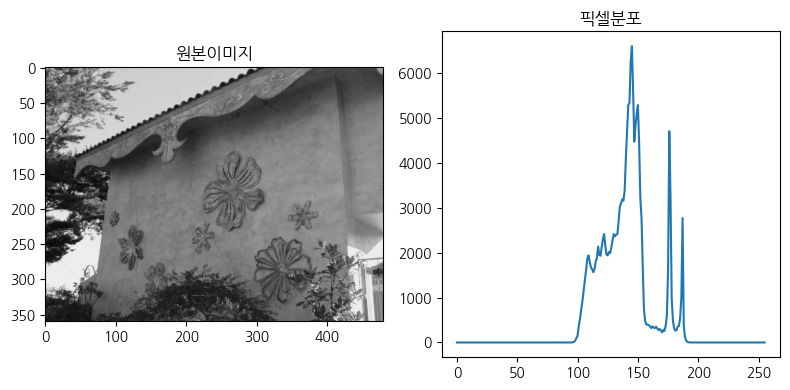

In [30]:
## 픽셀의 분포 확인
mountHist = cv2.calcHist([mountNP], [0], None, [256], [0, 256])

printPlotImage(1, 2, ['원본이미지', '픽셀분포'], [mountHist], [mountNP], ['gray'])

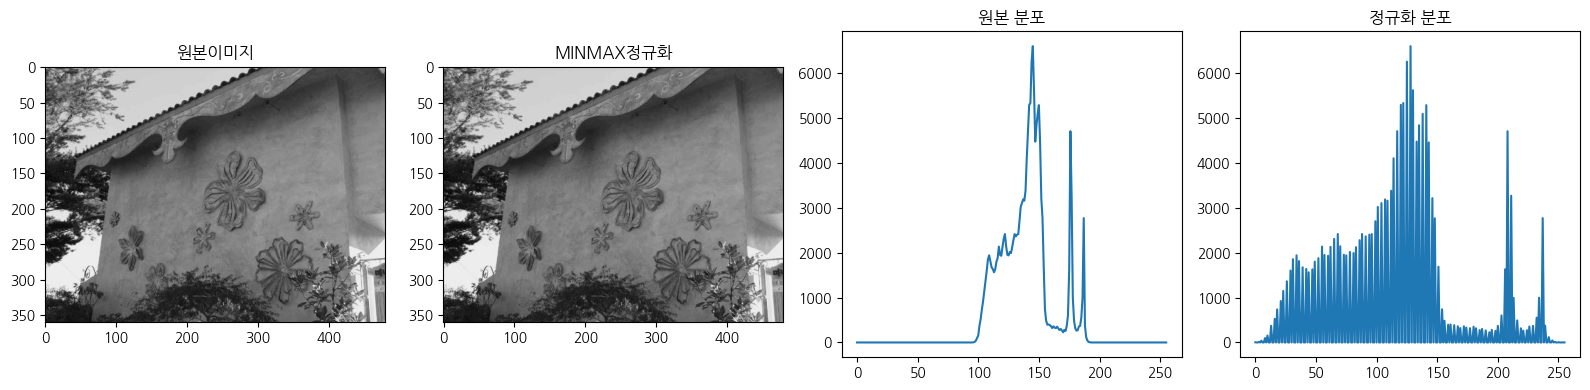

In [ ]:
## 픽셀 100 ~ 200 사이에 집중됨. 0~100/200~255픽셀 없음 ==> 정규화 진행
mmNP = cv2.normalize(mountNP, None, 0, 255, cv2.NORM_MINMAX)

mmHist = cv2.calcHist([mmNP], [0], None, [256], [0, 256])

printPlotImage(1, 4, ['원본이미지', 'MINMAX정규화', '원본 분포', '정규화 분포'], 
                     [mountHist, mmHist], [mountNP, mmNP], ['gray'])